 <font size="10">**Notebook 04: Metadata addition**</font>
***

<div class="alert alert-info">
    
<b> <h1> ℹ️ <strong> <font size="6" color="black"> Important notebook information </font> </strong> </h1> </b>
    <hr>
    <font size="4" color="black">
        The purpose of this notebook is to add Supplementary_Table_01 metadata found with <a href="https://haniffalab_github_sup1_here/">supplementary table 1</a> into each anndata object  <br> <br>
    This notebook will also save a copy of the metadata with cell barcodes in index as a csv  <br> <br>
    The following script will update anndata objects made in script 01  <br> <br>
    This notebook used around 167GB of memory </font>

<div class="alert alert-block alert-warning">
    
<b> <h1> ⚠️ <strong> <font size="6" color="black"> WARNING </font> </strong> ⚠️ </h1> </b>
    <hr>
<p style="color:black;">
    
<strong> <font size="4">  This script requires a large amount of memory to run as is from top to bottom. </font> </strong> <br> </p>
    <br>
<details> 
    <summary> <font size="4" color="black"> Memory amount </font> </summary> <br/>
    <font size="3" color="black">
        To run this script from top to bottom, the reading memory peaks at 167GB. <br> <br>
        The majority of the memory usage is used when both loading and saving the anndata objects <br> <br>
        Note these peaks were monitored using Grafana not Jupyter lab memory bar which suggested the rough peak memory usage was around 160GB
    </font> 
</details>

<br>

<details> 
    <summary> <font size="4" color="black"> Resource availability </font> </summary> <br/>
    <font size="3" color="black">
        The resources used to run this script with high reading memory capabilities and monitor the memory usage using Grafana was provided by <a href="https://www.sanger.ac.uk/group/cellular-genetics-informatics/">Cellular Genetics Informatics</a>
    </font>
</details>

<br>
    
<details>
    <summary> <font size="4" color="black"> Options to decrease memory </font> </summary> <br/>
    <font size="3" color="black">
        If you are only interested in a specific sample or one of the combined sample anndata objects comment out in appropriate sections code relating to the objects not interested in <br> <br>
        This approach can be used to add metadata to each of the anndata objects you are interested in
    </font>
</details>
</div>

***
# Import packages

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import os
import sys
import datetime

#to set unique date for outputs
calc_date = datetime.datetime.now()
date=calc_date.strftime('%Y-%m-%d')
#date=calc_date.strftime('%d-%m-%Y')
date = date.replace('-', '')

sc.settings.verbosity = 2

# Note: package versions can be located in dependencies at the bottom of the script

# User interaction block

In [ ]:
### User settings block ###

# Set root directory so all files and outputs can be found within one overarching location
root_directory = '/home/jovyan/mount_farm/nfs/ar32/Whole_embryo/'


# set directory path to Whole_Embryo_utils.py: This python script hold modules / functions which are used within the script 
Whole_Embryo_utils_path = root_directory + "Utlis/"


# set directory paths for each embryo cellranger outputs:
F137_path = root_directory + 'Outputs/Objects/Raw_Objects/F137_all_lanes_raw_counts_20220425.h5ad'
F147_path = root_directory + 'Outputs/Objects/Raw_Objects/F147_all_lanes_raw_counts_20220425.h5ad'
F158_path = root_directory + 'Outputs/Objects/Raw_Objects/F158_all_lanes_raw_counts_20220425.h5ad'
Comb_all_lanes_path = root_directory + 'Outputs/Objects/Raw_Objects/Combined_Embryos_all_lanes_raw_counts_20220425.h5ad'
Comb_suitable_lanes_path = root_directory + 'Outputs/Objects/Raw_Objects/Combined_Embryos_all_suitable_lanes_raw_counts_20220425.h5ad'

# set directory path for reading in metadata provided: Supplementary Table 01
Metadata_path = root_directory + 'QC/04_Metadata/Supplementary_Table_01_20220424.csv'

# Select column position in metadata to act as index : this should be your unique sample ID
index_col_position = 1

# set directory path to save copy of Metadata for each anndata object:
Metadata_out_path = root_directory + 'Outputs/Metadata/'


#############################################################################################################################


### Running checking directory paths to Whole_Embryo_utils.py and save directory paths ###

sys.path.append(Whole_Embryo_utils_path)
import Whole_Embryo_utils as eu

print('Checking file path for loading metadata:', "\n")
eu.save_path(Metadata_path)
print("")
print('Checking file path for saving metadata:', "\n")
eu.save_path(Metadata_out_path)

Checking file path for loading metadata: 

File path provided exists
To save data to this location use the inputed variable at the start of the file path

Checking file path for saving metadata: 

File path provided exists
To save data to this location use the inputed variable at the start of the file path


# Script start

In [ ]:
# Load in anndata objects and Supplementary_Table_01 metadata
print("="*100)
print("")
print('\033[1m' + 'Anndata object to load: F137'+ '\033[0m')
F137 = eu.load(F137_path, Method='h5ad')
print("="*100, "\n")
print('\033[1m' + 'Anndata object to load: F147'+ '\033[0m')
F147 = eu.load(F147_path, Method='h5ad')
print("="*100, "\n")
print('\033[1m' + 'Anndata object to load: F158'+ '\033[0m')
F158 = eu.load(F158_path, Method='h5ad')
print("="*100, "\n")
print('\033[1m' + 'Anndata object to load: Combined_embryos_all_lanes'+ '\033[0m')
Combined_embryos_all_lanes = eu.load(Comb_all_lanes_path, Method='h5ad')
print("="*100, "\n")
print('\033[1m' + 'Anndata object to load: Combined_embryos_all_suitable_lanes'+ '\033[0m')
Combined_embryos_all_suitable_lanes = eu.load(Comb_suitable_lanes_path, Method='h5ad')
print("="*100, "\n")
print('\033[1m' + 'Metadata to load: Supplementary_Table_01'+ '\033[0m', '\n')
Metadata = pd.read_csv(Metadata_path, index_col=index_col_position)
print('Metadata loaded in successfully', '\n')
print("="*100)


Anndata object to load: F137
Beginning to load data:
Method chosen for loading is h5ad out of the options: h5ad , h5 or mtx

Data loaded in successfully
Overall shape: (330792, 36601)
Min count: 0.0
Max count: 16057.0


Anndata object to load: F147
Beginning to load data:
Method chosen for loading is h5ad out of the options: h5ad , h5 or mtx

Data loaded in successfully
Overall shape: (462676, 36601)
Min count: 0.0
Max count: 12734.0


Anndata object to load: F158
Beginning to load data:
Method chosen for loading is h5ad out of the options: h5ad , h5 or mtx

Data loaded in successfully
Overall shape: (406519, 36601)
Min count: 0.0
Max count: 15643.0


Anndata object to load: Combined_embryos_all_lanes
Beginning to load data:
Method chosen for loading is h5ad out of the options: h5ad , h5 or mtx

Data loaded in successfully
Overall shape: (1199987, 36601)
Min count: 0.0
Max count: 16057.0


Anndata object to load: Combined_embryos_all_suitable_lanes
Beginning to load data:
Method chose

# Determining sex for each embryo
- Supplementary_Table_01_Metadata provided already contains gender information however this was determined after recieving data
- Plotting markers to confirm gender for each embryo

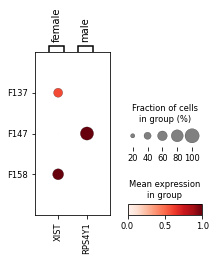

In [ ]:
# Show gender across each biological sample
cwd = os.getcwd()
os.chdir(Metadata_out_path)
gender_markers = {'female':['XIST'], 'male':['RPS4Y1']}
sc.pl.dotplot(Combined_embryos_all_lanes, groupby='haniffa_ID', var_names=gender_markers, figsize=(3,3), standard_scale='var', save='Sex_dotplot__for_Whole_embryo_samples_20220424.pdf')
os.chdir(cwd)

# Mapping metadata to each anndata object
- For each individual embryo add the relevant Supplementary_Table_01 metadata to all lanes both suitable and unsuitable
- For the combined embryo anndata object this will only add Supplementary_Table_01 metadata for lanes suitable for downstream analysis which was cut in script 01 
- For each anndata object save a copy of the metadata as a csv 

In [ ]:
# Add metadata to each anndata object 
anndata_objects = [F137,F147,F158,Combined_embryos_all_lanes,Combined_embryos_all_suitable_lanes]
for anndata_object in anndata_objects:
        for i in anndata_object.obs['sequencing_lane_ID'].unique():
            for col in Metadata.columns:
                anndata_object.obs.loc[anndata_object.obs['sequencing_lane_ID'].isin([i]), col] = Metadata.loc[i,col]
        for int_col in ['HDBR_ID','age_in_cs']:
            anndata_object.obs[int_col] = anndata_object.obs[int_col].astype(int)
        dataset_column = anndata_object.obs.pop('dataset')
        anndata_object.obs.insert(0, 'dataset', dataset_column)

######################################################################################################################################                   
                    
# Check the metadata for each anndata object
print("="*200, "\n")
print('\033[1m' + 'F137.obs :' + '\033[0m')
display(F137.obs)
print("")
print("="*200, "\n")
print('\033[1m' + 'F147.obs :' + '\033[0m')
display(F147.obs)
print("")
print("="*200, "\n")
print('\033[1m' + 'F158.obs :' + '\033[0m')
display(F158.obs)
print("")
print("="*200, "\n")
print('\033[1m' + 'Combined_embryos_all_lanes.obs :' + '\033[0m')
display(Combined_embryos_all_lanes.obs)
print("")
print("="*200, "\n")
print('\033[1m' + 'Combined_embryos_all_suitable_lanes.obs :' + '\033[0m')
display(Combined_embryos_all_suitable_lanes.obs)
print("")
print("="*200)
      
######################################################################################################################################   

# Save the metadata for each anndata object 
F137.obs.to_csv(Metadata_out_path+'F137_Supplementary_Table_01_metadata_' + date + '.csv')
F147.obs.to_csv(Metadata_out_path+'F147_Supplementary_Table_01_metadata_' + date + '.csv')
F158.obs.to_csv(Metadata_out_path+'F158_Supplementary_Table_01_metadata_' + date + '.csv')
Combined_embryos_all_lanes.obs.to_csv(Metadata_out_path+'Combined_embryos_all_lanes_Supplementary_Table_01_metadata_' + date + '.csv')
Combined_embryos_all_suitable_lanes.obs.to_csv(Metadata_out_path+'Combined_embryos_all_suitable_lanes_Supplementary_Table_01_metadata_' + date + '.csv')


F137.obs :


,dataset,sequencing_lane_ID,haniffa_ID,HDBR_ID,sequencing_type,10x_kit,spatial_location,spatial_location_replicates,sort_ID,procedure,age_in_cs,sex,alignment_software,alignment_reference
AAACCTGAGATCCGAG-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGAGTACGATA-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGCAGGTCCAC-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGGTACCTACA-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGGTATTCTCT-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTGACCAAG-WS_wEMB10202380,whole_embryo,WS_wEMB10202380,F137,15702,chromium_5_prime,5_prime_V1,Section_12,Section_12_d,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
TTTGTCAGTTCCAACA-WS_wEMB10202380,whole_embryo,WS_wEMB10202380,F137,15702,chromium_5_prime,5_prime_V1,Section_12,Section_12_d,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCAAACAAG-WS_wEMB10202380,whole_embryo,WS_wEMB10202380,F137,15702,chromium_5_prime,5_prime_V1,Section_12,Section_12_d,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCCAATGGT-WS_wEMB10202380,whole_embryo,WS_wEMB10202380,F137,15702,chromium_5_prime,5_prime_V1,Section_12,Section_12_d,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A




F147.obs :


,dataset,sequencing_lane_ID,haniffa_ID,HDBR_ID,sequencing_type,10x_kit,spatial_location,spatial_location_replicates,sort_ID,procedure,age_in_cs,sex,alignment_software,alignment_reference
AAACCTGAGCCAGGAT-WS_wEMB11031919,whole_embryo,WS_wEMB11031919,F147,15942,chromium_5_prime,5_prime_V2,Section_01,Section_01_a,live_single,medical,16,male,cellranger_6-0-1,GRCh38-2020-A
AAACCTGAGGACCACA-WS_wEMB11031919,whole_embryo,WS_wEMB11031919,F147,15942,chromium_5_prime,5_prime_V2,Section_01,Section_01_a,live_single,medical,16,male,cellranger_6-0-1,GRCh38-2020-A
AAACCTGAGGCGACAT-WS_wEMB11031919,whole_embryo,WS_wEMB11031919,F147,15942,chromium_5_prime,5_prime_V2,Section_01,Section_01_a,live_single,medical,16,male,cellranger_6-0-1,GRCh38-2020-A
AAACCTGAGGGATACC-WS_wEMB11031919,whole_embryo,WS_wEMB11031919,F147,15942,chromium_5_prime,5_prime_V2,Section_01,Section_01_a,live_single,medical,16,male,cellranger_6-0-1,GRCh38-2020-A
AAACCTGAGTATGACA-WS_wEMB11031919,whole_embryo,WS_wEMB11031919,F147,15942,chromium_5_prime,5_prime_V2,Section_01,Section_01_a,live_single,medical,16,male,cellranger_6-0-1,GRCh38-2020-A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCATTTGGG-WS_wEMB11031966,whole_embryo,WS_wEMB11031966,F147,15942,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,16,male,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCCAGTAGT-WS_wEMB11031966,whole_embryo,WS_wEMB11031966,F147,15942,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,16,male,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCCCGACTT-WS_wEMB11031966,whole_embryo,WS_wEMB11031966,F147,15942,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,16,male,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCCGGGTGT-WS_wEMB11031966,whole_embryo,WS_wEMB11031966,F147,15942,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,16,male,cellranger_6-0-1,GRCh38-2020-A




F158.obs :


,dataset,sequencing_lane_ID,haniffa_ID,HDBR_ID,sequencing_type,10x_kit,spatial_location,spatial_location_replicates,sort_ID,procedure,age_in_cs,sex,alignment_software,alignment_reference
AAACCTGAGACCCACC-WS_wEMB12142105,whole_embryo,WS_wEMB12142105,F158,16099,chromium_5_prime,5_prime_V2,Section_01,Section_01_a,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGAGATATACG-WS_wEMB12142105,whole_embryo,WS_wEMB12142105,F158,16099,chromium_5_prime,5_prime_V2,Section_01,Section_01_a,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGAGCTAACAA-WS_wEMB12142105,whole_embryo,WS_wEMB12142105,F158,16099,chromium_5_prime,5_prime_V2,Section_01,Section_01_a,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGAGGCGCTCT-WS_wEMB12142105,whole_embryo,WS_wEMB12142105,F158,16099,chromium_5_prime,5_prime_V2,Section_01,Section_01_a,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGAGGGCTTGA-WS_wEMB12142105,whole_embryo,WS_wEMB12142105,F158,16099,chromium_5_prime,5_prime_V2,Section_01,Section_01_a,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCAGCATGT-WS_wEMB12142155,whole_embryo,WS_wEMB12142155,F158,16099,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCAGTCCCT-WS_wEMB12142155,whole_embryo,WS_wEMB12142155,F158,16099,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCCCTTGCA-WS_wEMB12142155,whole_embryo,WS_wEMB12142155,F158,16099,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCCTCATTA-WS_wEMB12142155,whole_embryo,WS_wEMB12142155,F158,16099,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A




Combined_embryos_all_lanes.obs :


,dataset,sequencing_lane_ID,haniffa_ID,HDBR_ID,sequencing_type,10x_kit,spatial_location,spatial_location_replicates,sort_ID,procedure,age_in_cs,sex,alignment_software,alignment_reference
AAACCTGAGATCCGAG-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGAGTACGATA-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGCAGGTCCAC-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGGTACCTACA-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGGTATTCTCT-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCAGCATGT-WS_wEMB12142155,whole_embryo,WS_wEMB12142155,F158,16099,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCAGTCCCT-WS_wEMB12142155,whole_embryo,WS_wEMB12142155,F158,16099,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCCCTTGCA-WS_wEMB12142155,whole_embryo,WS_wEMB12142155,F158,16099,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCCTCATTA-WS_wEMB12142155,whole_embryo,WS_wEMB12142155,F158,16099,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A




Combined_embryos_all_suitable_lanes.obs :


,dataset,sequencing_lane_ID,haniffa_ID,HDBR_ID,sequencing_type,10x_kit,spatial_location,spatial_location_replicates,sort_ID,procedure,age_in_cs,sex,alignment_software,alignment_reference
AAACCTGAGATCCGAG-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGAGTACGATA-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGCAGGTCCAC-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGGTACCTACA-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
AAACCTGGTATTCTCT-WS_wEMB10202336,whole_embryo,WS_wEMB10202336,F137,15702,chromium_5_prime,5_prime_V1,Section_01,Section_01_a,live_single,medical,16,female,cellranger_6-0-1,GRCh38-2020-A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCAGCATGT-WS_wEMB12142155,whole_embryo,WS_wEMB12142155,F158,16099,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCAGTCCCT-WS_wEMB12142155,whole_embryo,WS_wEMB12142155,F158,16099,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCCCTTGCA-WS_wEMB12142155,whole_embryo,WS_wEMB12142155,F158,16099,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A
TTTGTCATCCTCATTA-WS_wEMB12142155,whole_embryo,WS_wEMB12142155,F158,16099,chromium_5_prime,5_prime_V2,Section_12,Section_12_d,live_single,medical,17,female,cellranger_6-0-1,GRCh38-2020-A


# Review metadata
- This will only be done for the combined embryo object as this is the object which will be used for downstream analysis as only contains suitable lanes of interest
- This will not add any further information to the metadata

In [ ]:
pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', 150)

print('\033[1m' +"Column dtypes:"+ '\033[0m')
display(Combined_embryos_all_suitable_lanes.obs.info())
print("","\n")
print('\033[1m' +"Number of cells grouped by: embryo -> spatial_location -> spatial_location_repliactes:"+ '\033[0m')
display(Combined_embryos_all_suitable_lanes.obs.groupby(['haniffa_ID','spatial_location','spatial_location_replicates','sequencing_lane_ID']).apply(len))
Cell_numbers_table = pd.DataFrame(Combined_embryos_all_suitable_lanes.obs.groupby(['haniffa_ID','spatial_location','spatial_location_replicates','sequencing_lane_ID']).apply(len))
Cell_numbers_table.rename(columns = {0:'No_Cells'}, inplace = True)
Cell_numbers_table.to_csv(Metadata_out_path + 'Combined_Embryos_all_suitable_lanes_raw_cell_numbers_per_lane_' + date + '.csv')

Column dtypes:
<class 'pandas.core.frame.DataFrame'>
Index: 1183081 entries, AAACCTGAGATCCGAG-WS_wEMB10202336 to TTTGTCATCCTTCAAT-WS_wEMB12142155
Data columns (total 14 columns):
 #   Column                       Non-Null Count    Dtype   
---  ------                       --------------    -----   
 0   dataset                      1183081 non-null  object  
 1   sequencing_lane_ID           1183081 non-null  category
 2   haniffa_ID                   1183081 non-null  category
 3   HDBR_ID                      1183081 non-null  int64   
 4   sequencing_type              1183081 non-null  object  
 5   10x_kit                      1183081 non-null  object  
 6   spatial_location             1183081 non-null  object  
 7   spatial_location_replicates  1183081 non-null  object  
 8   sort_ID                      1183081 non-null  object  
 9   procedure                    1183081 non-null  object  
 10  age_in_cs                    1183081 non-null  int64   
 11  sex                    

None

 

Number of cells grouped by: embryo -> spatial_location -> spatial_location_repliactes:


haniffa_ID  spatial_location  spatial_location_replicates  sequencing_lane_ID
F137        Section_01        Section_01_a                 WS_wEMB10202336        2068
            Section_02        Section_02_a                 WS_wEMB10202337        9303
                              Section_02_b                 WS_wEMB10202338        9380
                              Section_02_c                 WS_wEMB10202339        9223
                              Section_02_d                 WS_wEMB10202340        7515
            Section_03        Section_03_a                 WS_wEMB10202341        9679
                              Section_03_b                 WS_wEMB10202342       10539
                              Section_03_c                 WS_wEMB10202343        9504
                              Section_03_d                 WS_wEMB10202344        9489
            Section_04        Section_04_a                 WS_wEMB10202345        6809
                              Section_04_b          

# Save anndata objects
- Overwrite the anndata objects loaded in so they now also store the Supplementary_Table_01 metadata for user ease

In [ ]:
F137.write_h5ad(F137_path)
F147.write_h5ad(F147_path)
F158.write_h5ad(F158_path)
Combined_embryos_all_lanes.write_h5ad(Comb_all_lanes_path)
Combined_embryos_all_suitable_lanes.write_h5ad(Comb_suitable_lanes_path)

... storing 'dataset' as categorical
... storing 'sequencing_type' as categorical
... storing '10x_kit' as categorical
... storing 'spatial_location' as categorical
... storing 'spatial_location_replicates' as categorical
... storing 'sort_ID' as categorical
... storing 'procedure' as categorical
... storing 'sex' as categorical
... storing 'alignment_software' as categorical
... storing 'alignment_reference' as categorical
... storing 'dataset' as categorical
... storing 'sequencing_type' as categorical
... storing '10x_kit' as categorical
... storing 'spatial_location' as categorical
... storing 'spatial_location_replicates' as categorical
... storing 'sort_ID' as categorical
... storing 'procedure' as categorical
... storing 'sex' as categorical
... storing 'alignment_software' as categorical
... storing 'alignment_reference' as categorical
... storing 'dataset' as categorical
... storing 'sequencing_type' as categorical
... storing '10x_kit' as categorical
... storing 'spatial_loca

***
### Dependencies
Here are some information about resources and import package versions used within this script

In [1]:
%load_ext watermark
%watermark -v -m -p numpy,pandas,scanpy,anndata

Python implementation: CPython
Python version       : 3.9.4
IPython version      : 7.24.1

numpy  : 1.20.3
pandas : 1.2.4
scanpy : 1.7.2
anndata: 0.7.6

Compiler    : GCC 9.3.0
OS          : Linux
Release     : 4.15.0-112-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 26
Architecture: 64bit

